# TP7 — Classification Chest X-Ray avec CNN
**Dataset :** chest_xray (NORMAL vs PNEUMONIA)

Ce notebook adapte la structure du TP MNIST pour classifier des radiographies thoraciques.

In [5]:
# ============================================================
# CELLULE 1 — Imports
# ============================================================
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from google.colab import drive
import random

In [6]:
# ============================================================
# CELLULE 2 — Monter Google Drive
# ============================================================
drive.mount('/content/drive')

# Chemin vers le dataset chest_xray
data_dir = '/content/drive/MyDrive/tp7/chest_xray'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
# ============================================================
# CELLULE 3 — Chargement des données (DataLoader)
# ============================================================
from torch.utils.data import DataLoader, ConcatDataset, random_split

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=1),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Fusionner train + val original (car val = 16 images seulement)
train_raw = torchvision.datasets.ImageFolder(root=data_dir + '/train')
val_raw   = torchvision.datasets.ImageFolder(root=data_dir + '/val')
test_dataset = torchvision.datasets.ImageFolder(
    root=data_dir + '/test', transform=val_test_transform)

# Recouper : 85% train, 15% val sur (train+val fusionnés)
full_train = ConcatDataset([train_raw, val_raw])
total = len(full_train)
val_size   = int(0.15 * total)
train_size = total - val_size
train_split, val_split = random_split(full_train, [train_size, val_size],
                                       generator=torch.Generator().manual_seed(42))

# Appliquer les transforms via un wrapper
class TransformDataset(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform
    def __len__(self):
        return len(self.subset)
    def __getitem__(self, idx):
        img, label = self.subset[idx]
        return self.transform(img), label

train_dataset = TransformDataset(train_split, train_transform)
val_dataset   = TransformDataset(val_split,   val_test_transform)

batch_size_train = 32   # réduit pour stabiliser
batch_size_test  = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size_train,
                          shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size_test,
                          shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size_test,
                          shuffle=False, num_workers=2)

print('Classes :', train_raw.classes)
print('Train :', len(train_dataset), '— Val :', len(val_dataset), '— Test :', len(test_dataset))

Classes : ['NORMAL', 'PNEUMONIA']
Train : 4448 — Val : 784 — Test : 624


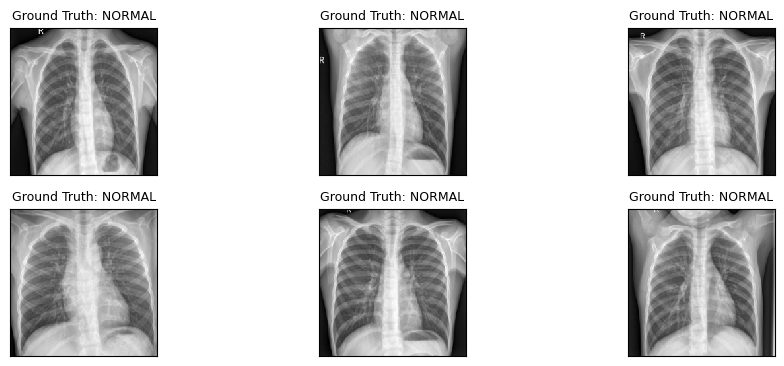

In [8]:
# ============================================================
# CELLULE 4 — Visualisation de quelques images du test set
# ============================================================
examples = enumerate(test_loader)
batch_idx, (example_data, example_targets) = next(examples)

class_names = train_raw.classes  # ← utiliser train_raw qui a l'attribut classes

fig = plt.figure(figsize=(10, 4))
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.tight_layout()
    plt.imshow(example_data[i][0], cmap='gray', interpolation='none')
    label = class_names[example_targets[i].item()]
    plt.title('Ground Truth: {}'.format(label), fontsize=9)
    plt.xticks([])
    plt.yticks([])
plt.show()

## Définition du réseau CNN

On définit une classe `Net` héritant de `nn.Module`. Le constructeur `__init__` déclare toutes les couches, et la méthode `forward` décrit le passage avant (forward pass).

**Architecture (TODO complétés) :**
1. Conv valide 5×5 — 1 → 32 canaux
2. MaxPool 2×2
3. ReLU
4. Conv valide 5×5 — 32 → 64 canaux
5. Dropout2D
6. MaxPool 2×2
7. ReLU
8. Conv valide 3×3 — 64 → 128 canaux (couche supplémentaire pour chest x-ray)
9. Flatten
10. FC → 512, ReLU
11. FC → 128, ReLU
12. FC → 2, LogSoftmax

In [9]:
# ============================================================
# CELLULE 5 — Définition du réseau CNN (TODO complétés)
# ============================================================

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()

        # TODO 1 : Convolution valide, kernel 5, 1 canal entrée -> 32 canaux sortie
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=5)
        # BatchNorm stabilise l'entraînement après chaque conv
        self.bn1   = nn.BatchNorm2d(32)

        # TODO 4 : Convolution valide, kernel 5, 32 canaux -> 64 canaux
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=5)
        # TODO 5 : Dropout 2D (éteint des canaux entiers pour éviter l'overfitting)
        self.conv2_drop = nn.Dropout2d(p=0.25)
        self.bn2   = nn.BatchNorm2d(64)

        # Couche supplémentaire pour capturer plus de features sur chest x-ray
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3)
        self.conv3_drop = nn.Dropout2d(p=0.25)
        self.bn3   = nn.BatchNorm2d(128)

        # TODO 9 : Calcul automatique de la taille avant la couche FC
        # On fait un forward 'fantôme' pour trouver la bonne dimension
        self._flat_size = self._get_flat_size()

        # TODO 9 : FC mapping de la taille calculée -> 512
        self.fc1 = nn.Linear(self._flat_size, 512)
        # TODO 11 : FC 512 -> 128
        self.fc2 = nn.Linear(512, 128)
        # FC final : 128 -> 2 classes (NORMAL ou PNEUMONIA)
        self.fc3 = nn.Linear(128, 2)

        # Dropout pour les couches fully connected
        self.dropout = nn.Dropout(p=0.5)

    def _get_flat_size(self):
        """Calcule automatiquement la taille du vecteur après les convolutions.
        Cela évite de calculer à la main en fonction de la taille d'entrée."""
        with torch.no_grad():
            dummy = torch.zeros(1, 1, 224, 224)
            dummy = F.max_pool2d(F.relu(self.bn1(self.conv1(dummy))), 2)
            dummy = F.max_pool2d(F.relu(self.bn2(self.conv2_drop(self.conv2(dummy)))), 2)
            dummy = F.max_pool2d(F.relu(self.bn3(self.conv3_drop(self.conv3(dummy)))), 2)
            return dummy.view(1, -1).shape[1]

    def forward(self, x):

        # --- BLOC CONVOLUTIF 1 ---
        # TODO 1 : convolution valide kernel 5 (1 -> 32 canaux)
        x = self.conv1(x)
        x = self.bn1(x)
        # TODO 2 : max pooling 2x2
        x = F.max_pool2d(x, 2)
        # TODO 3 : ReLU
        x = F.relu(x)

        # --- BLOC CONVOLUTIF 2 ---
        # TODO 4 : convolution valide kernel 5 (32 -> 64 canaux)
        x = self.conv2(x)
        # TODO 5 : Dropout 2D
        x = self.conv2_drop(x)
        x = self.bn2(x)
        # TODO 6 : max pooling 2x2
        x = F.max_pool2d(x, 2)
        # TODO 7 : ReLU
        x = F.relu(x)

        # --- BLOC CONVOLUTIF 3 ---
        x = self.conv3(x)
        x = self.conv3_drop(x)
        x = self.bn3(x)
        x = F.max_pool2d(x, 2)
        x = F.relu(x)

        # TODO 8 : Flatten — aplatir en vecteur 1D
        x = x.view(x.size(0), -1)

        # TODO 9 & 10 : FC1 -> 512, ReLU
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout(x)

        # TODO 11 : FC2 -> 128, ReLU
        x = self.fc2(x)
        x = F.relu(x)
        x = self.dropout(x)

        # FC final -> 2 classes
        x = self.fc3(x)

        # TODO 12 : LogSoftmax (compatible avec nll_loss)
        return F.log_softmax(x, dim=1)

In [10]:
# ============================================================
# CELLULE 6 — He initialization
# ============================================================
def weights_init(layer_in):
    if isinstance(layer_in, nn.Linear):
        nn.init.kaiming_uniform_(layer_in.weight)
        layer_in.bias.data.fill_(0.0)
    elif isinstance(layer_in, nn.Conv2d):
        nn.init.kaiming_uniform_(layer_in.weight)
        if layer_in.bias is not None:
            layer_in.bias.data.fill_(0.0)

In [ ]:
# ============================================================
# CELLULE 7 — Modèle, GPU, optimiseur
# ============================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device :', device)

model = Net()
model.apply(weights_init)
model = model.to(device)

print('Flatten size :', model._flat_size)
print('Paramètres :', sum(p.numel() for p in model.parameters() if p.requires_grad))

optimizer = optim.Adam(model.parameters(), lr=0.0003, weight_decay=1e-3)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=3, factor=0.5
)

Device : cuda
Flatten size : 80000
Paramètres : 41152834


In [12]:
# ============================================================
# CELLULE 8 — Fonction d'entraînement
# ============================================================

def train(epoch):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        # Déplacer les données sur GPU
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = F.nll_loss(output, target)
        loss.backward()
        optimizer.step()
        if batch_idx % 20 == 0:
            print('Train Epoch: {} [{}/{}]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(data),
                len(train_loader.dataset), loss.item()))

In [13]:
# ============================================================
# CELLULE 9 — Fonction de validation (pendant l'entraînement)
# ============================================================

def validate():
    model.eval()
    val_loss = 0
    correct  = 0
    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            val_loss += F.nll_loss(output, target, reduction='sum').item()
            pred = output.data.max(1, keepdim=True)[1]
            correct += pred.eq(target.data.view_as(pred)).sum()
    val_loss /= len(val_loader.dataset)
    acc = 100. * correct / len(val_loader.dataset)
    print('\nValidation — Avg. loss: {:.4f}, Accuracy: {}/{} ({:.1f}%)\n'.format(
        val_loss, correct, len(val_loader.dataset), acc))
    return acc.item()

In [14]:
# ============================================================
# CELLULE 10 — Fonction de test (évaluation finale)
# ============================================================

def test():
    model.eval()
    test_loss = 0
    correct   = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += F.nll_loss(output, target, reduction='sum').item()
            pred = output.data.max(1, keepdim=True)[1]
            correct += pred.eq(target.data.view_as(pred)).sum()
    test_loss /= len(test_dataset)
    print('\nTest set: Avg. loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
        test_loss, correct, len(test_dataset),
        100. * correct / len(test_dataset)))

In [15]:
# ============================================================
# CELLULE 11 — Entraînement
# ============================================================
test()

n_epochs = 10   # augmenté à 10
best_acc = 0

for epoch in range(1, n_epochs + 1):
    train(epoch)
    val_acc = validate()
    scheduler.step(val_acc)

    # Sauvegarder le meilleur modèle
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), '/content/best_model.pth')
        print(f'  >> Meilleur modèle sauvegardé (val acc = {val_acc:.1f}%)')

# Charger le meilleur modèle pour le test final
model.load_state_dict(torch.load('/content/best_model.pth'))
print('\n=== RÉSULTAT FINAL (meilleur modèle) ===')
test()


Test set: Avg. loss: 0.7413, Accuracy: 249/624 (40%)

Train Epoch: 1 [0/4448]	Loss: 1.684592
Train Epoch: 1 [640/4448]	Loss: 5.679468
Train Epoch: 1 [1280/4448]	Loss: 4.868003
Train Epoch: 1 [1920/4448]	Loss: 2.429109
Train Epoch: 1 [2560/4448]	Loss: 1.586278
Train Epoch: 1 [3200/4448]	Loss: 0.808814
Train Epoch: 1 [3840/4448]	Loss: 0.720796

Validation — Avg. loss: 0.1661, Accuracy: 731/784 (93.2%)

  >> Meilleur modèle sauvegardé (val acc = 93.2%)
Train Epoch: 2 [0/4448]	Loss: 0.502631
Train Epoch: 2 [640/4448]	Loss: 0.169540
Train Epoch: 2 [1280/4448]	Loss: 0.262592
Train Epoch: 2 [1920/4448]	Loss: 0.135498
Train Epoch: 2 [2560/4448]	Loss: 0.781922
Train Epoch: 2 [3200/4448]	Loss: 0.370134
Train Epoch: 2 [3840/4448]	Loss: 0.441020

Validation — Avg. loss: 0.1737, Accuracy: 724/784 (92.3%)

Train Epoch: 3 [0/4448]	Loss: 0.600642
Train Epoch: 3 [640/4448]	Loss: 0.285136
Train Epoch: 3 [1280/4448]	Loss: 0.457426
Train Epoch: 3 [1920/4448]	Loss: 0.391674
Train Epoch: 3 [2560/4448]	Loss

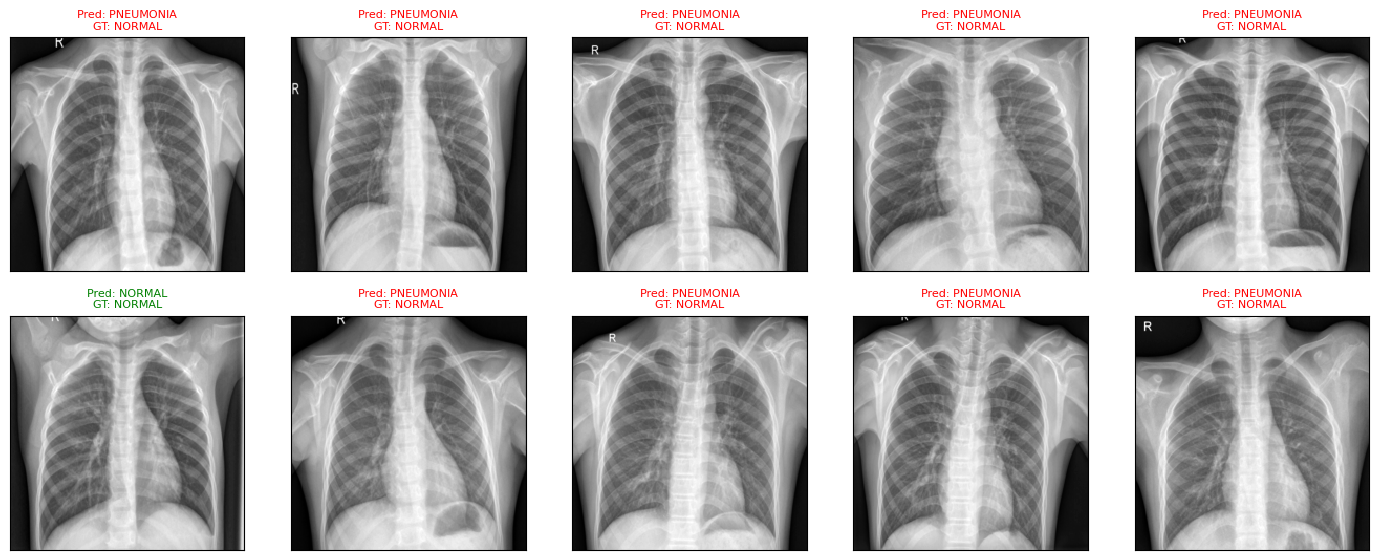

In [16]:
# ============================================================
# CELLULE 12 — Visualisation des prédictions
# ============================================================
model.eval()
output = model(example_data.to(device))

class_names = train_raw.classes  # ← idem

fig = plt.figure(figsize=(14, 6))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.tight_layout()
    plt.imshow(example_data[i][0].cpu(), cmap='gray', interpolation='none')
    pred_label = class_names[output.data.max(1, keepdim=True)[1][i].item()]
    true_label = class_names[example_targets[i].item()]
    color = 'green' if pred_label == true_label else 'red'
    plt.title('Pred: {}\nGT: {}'.format(pred_label, true_label),
              fontsize=8, color=color)
    plt.xticks([])
    plt.yticks([])
plt.show()